# Telco Customer Churn: KNN, Logistic Regression and Random Forest

## 1. Load and check the data

In [1]:
# Import and load the dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# check the data
df.info()
print(df.isna().sum().sum(),"missing values")
print(df.duplicated().sum(),"duplicate rows")


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# finding the problem in TotalCharges
print((df["TotalCharges"].str.strip() == "").sum(),"empty values in TotalCharges")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[df["TotalCharges"].isna()][["tenure","MonthlyCharges","TotalCharges"]]


11 empty values in TotalCharges


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


## 2. Clean the data

In [4]:
# clean the data
df["TotalCharges"] = df["TotalCharges"].fillna(0)                 # new customers → 0 charges
df = df.drop(columns="customerID")                                # ID is useless for prediction
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})                # target → 1/0
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})  # match other Yes/No columns
df.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## 3. Exploratory data analysis

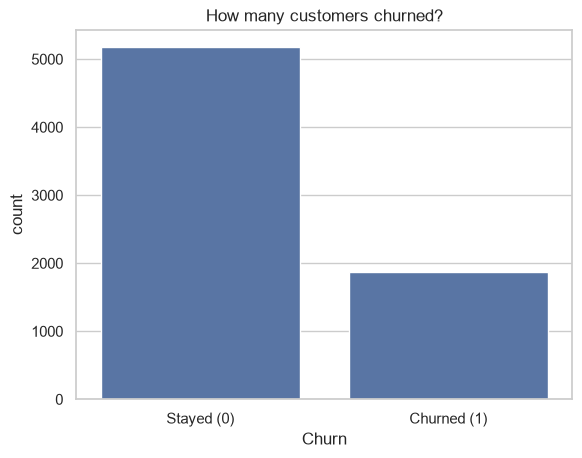

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [5]:
# class balance
ax = sns.countplot(x="Churn", data=df)
ax.set_xticks([0, 1], ["Stayed (0)", "Churned (1)"])
ax.set_title("How many customers churned?")
plt.savefig("figures/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
df["Churn"].value_counts(normalize=True)

**Insight:** 26.5% of customers churned and 73.5% stayed, so the classes are imbalanced. Accuracy alone would be misleading (predicting "stay" for everyone gives 73.5%), so models are compared mainly on **F1, recall and ROC-AUC**, the split is stratified, and `class_weight="balanced"` is tried during tuning.

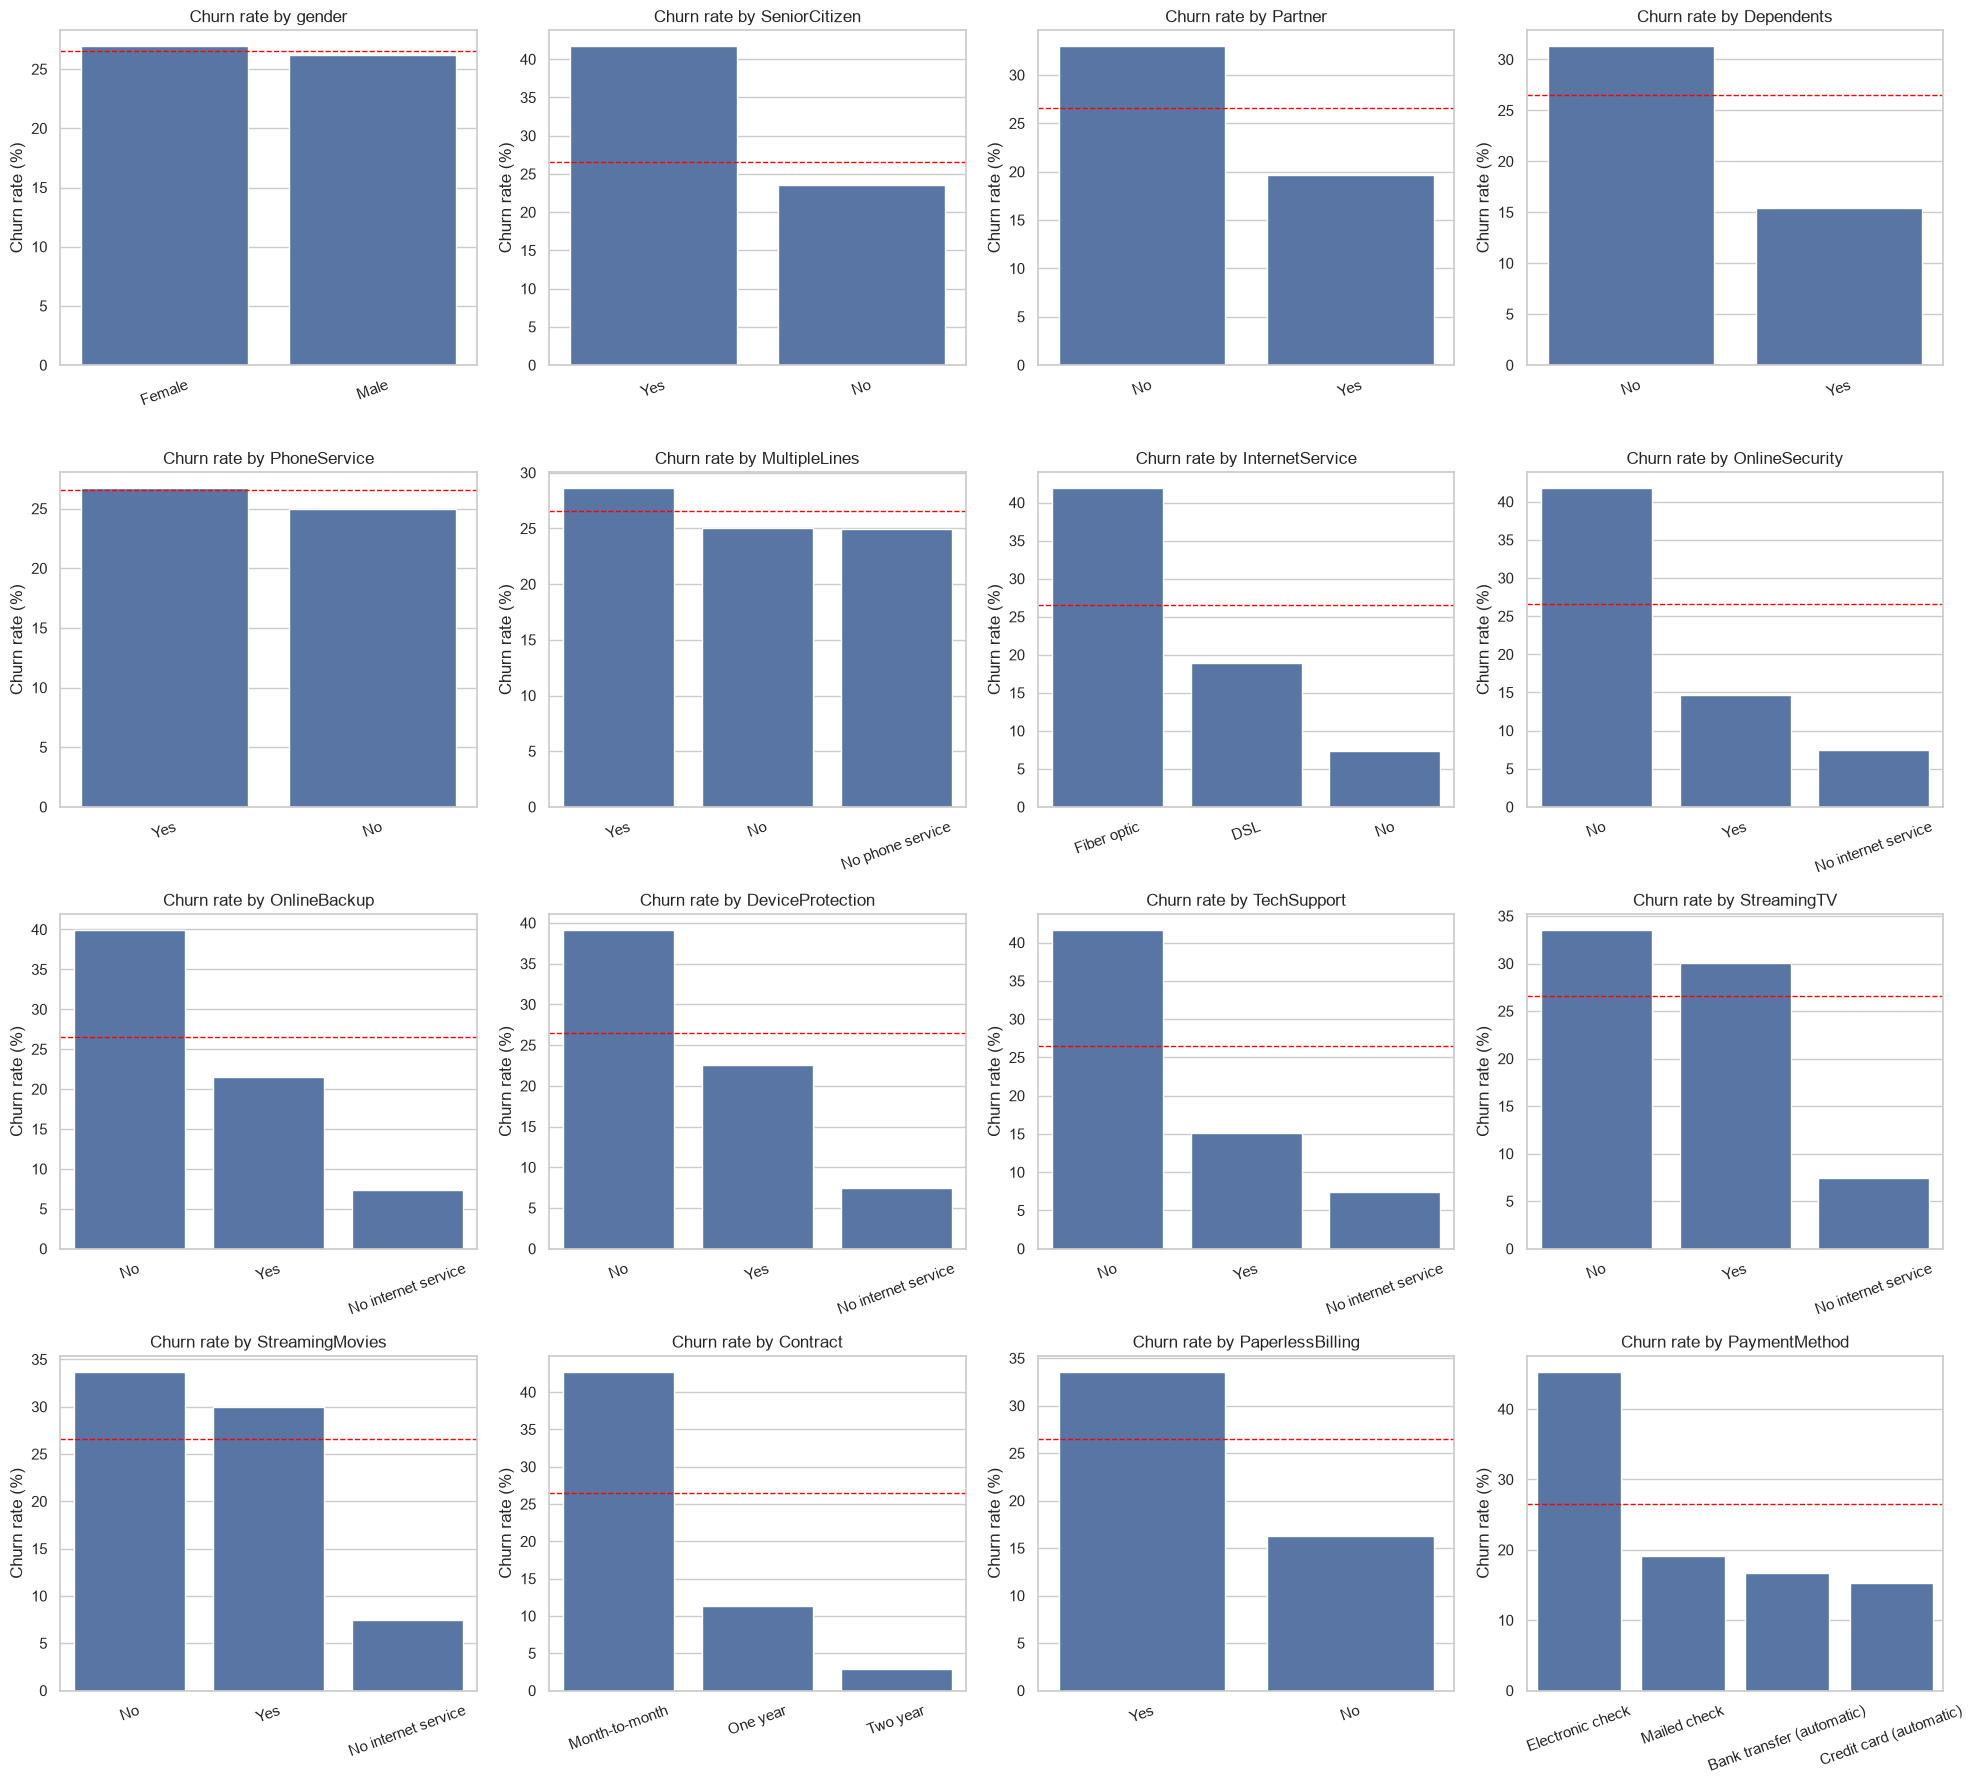

,Churn %,Customers,feature
Electronic check,45.3,2365,PaymentMethod
Month-to-month,42.7,3875,Contract
Fiber optic,41.9,3096,InternetService
No,41.8,3498,OnlineSecurity
Yes,41.7,1142,SeniorCitizen
No,41.6,3473,TechSupport
No,39.9,3088,OnlineBackup
No,39.1,3095,DeviceProtection
No,33.7,2785,StreamingMovies
Yes,33.6,4171,PaperlessBilling


In [6]:
# churn rate for every categorical column
cat_eda = df.select_dtypes(exclude="number").columns

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
for ax, col in zip(axes.flat, cat_eda):
    rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.axhline(df["Churn"].mean() * 100, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("figures/02_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

# churn rate per category, highest first
summary = pd.concat(
    [df.groupby(c)["Churn"].agg(["mean", "size"]).assign(feature=c) for c in cat_eda])
summary["mean"] = (summary["mean"] * 100).round(1)
summary.rename(columns={"mean": "Churn %", "size": "Customers"}).sort_values("Churn %", ascending=False).head(12)

**Insights** (red line = overall churn rate of 26.5%):
- **Contract** is the strongest signal: month-to-month 42.7% vs one-year 11.3% vs two-year 2.8%.
- **Fiber optic** customers churn at 41.9%, compared with 19.0% for DSL and 7.4% with no internet.
- **Electronic check** payers churn at 45.3%, roughly three times the automatic payment methods (15–17%).
- Customers **without OnlineSecurity or TechSupport** churn at about 42%, compared with about 15% for those who have them.
- **Senior citizens** churn more (41.7%), and so do customers without a partner or dependents and those on paperless billing.
- **Gender** and **PhoneService** make almost no difference (26.9% vs 26.2%; 24.9% vs 26.7%).

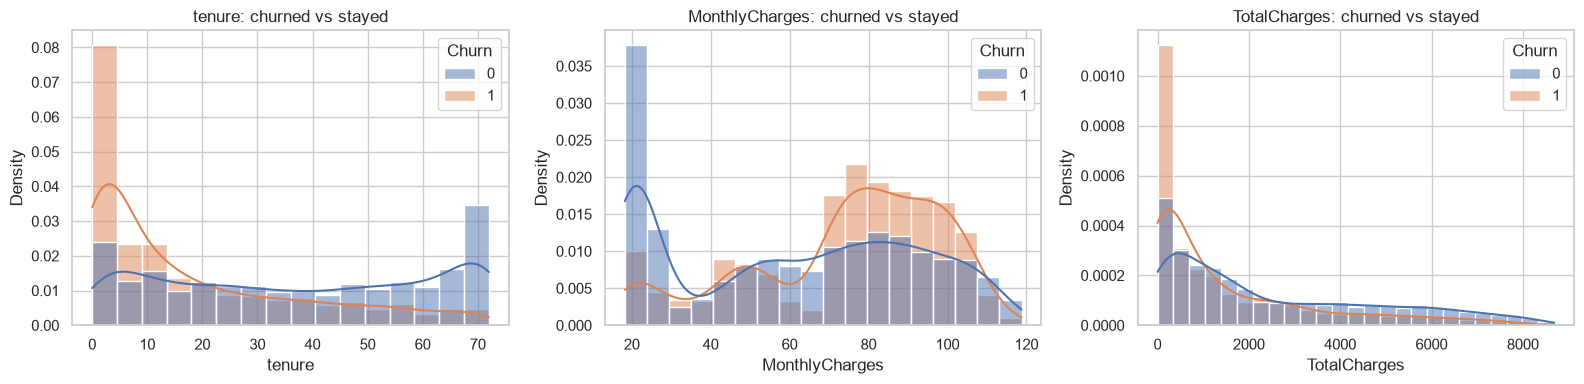

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550


In [7]:
# tenure and charges, churned vs stayed
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True,
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col}: churned vs stayed")
plt.tight_layout()
plt.savefig("figures/03_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
df.groupby("Churn")[num_cols].median()

**Insight:** churners have a much shorter tenure (median 10 vs 38 months) and higher monthly charges (median 79.65 vs 64.43). Their lower TotalCharges simply follows from the shorter tenure. Churn is concentrated in the first year.

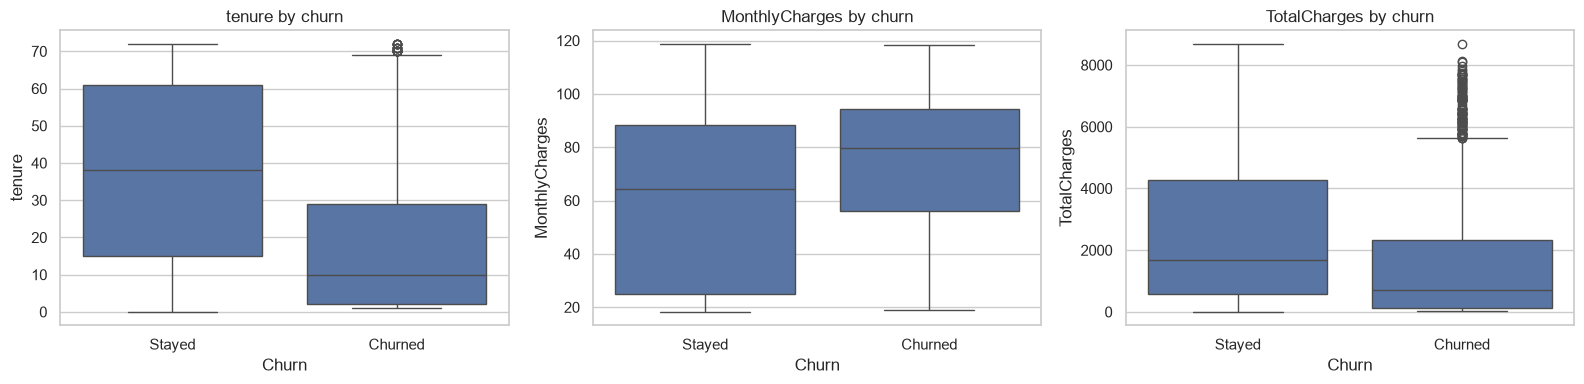

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [8]:
# outlier check (IQR rule)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_xticks([0, 1], ["Stayed", "Churned"])
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.savefig("figures/03b_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {n_out} outliers")

**Insight:** no values fall outside the 1.5 × IQR range for any numeric feature, so no outlier removal is needed. TotalCharges is right-skewed, and StandardScaler is applied to all numeric features because KNN and Logistic Regression are sensitive to scale.

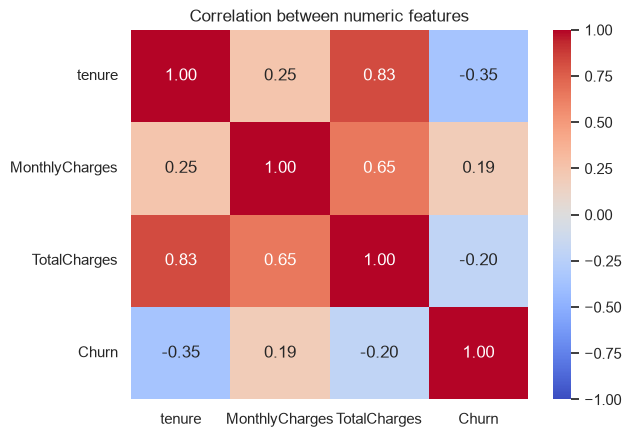

In [9]:
# correlation heatmap
corr = df[num_cols + ["Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.savefig("figures/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# is TotalCharges just tenure x MonthlyCharges?
estimate = df["tenure"] * df["MonthlyCharges"]
print("Correlation of TotalCharges with tenure x MonthlyCharges:",
      round(df["TotalCharges"].corr(estimate), 3))

Correlation of TotalCharges with tenure x MonthlyCharges: 1.0


**Insight:** TotalCharges is highly correlated with tenure (0.83) and is almost exactly tenure × MonthlyCharges (r ≈ 1.00), so it carries little new information. This multicollinearity can make Logistic Regression coefficients unstable. The column is kept because regularisation (L2) handles it, but it should be noted in the report. Tenure has the strongest (negative) correlation with churn.

## 4. Train/test split and preprocessing

In [11]:
# split into train and test sets
from sklearn.model_selection import train_test_split

X = df.drop(columns="Churn")   
y = df["Churn"]                

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5634, 19)  Test: (1409, 19)


In [12]:
# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                         
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),   
])

In [13]:
# A helper function that scores each model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

results = []

def evaluate(name, setting, model):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    row = {"Model": name, "Setting": setting,
           "Accuracy": accuracy_score(y_test, pred),
           "Precision": precision_score(y_test, pred),
           "Recall": recall_score(y_test, pred),
           "F1": f1_score(y_test, pred),
           "ROC-AUC": roc_auc_score(y_test, prob)}
    results.append(row)
    return row


## 5. Experiment 1: default hyperparameters

In [14]:
# Experiment 1, default hyperparameters (same preprocessing pipeline)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

default_models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
}

for name, clf in default_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)                  # ← this is the "training"
    print(evaluate(name, "Default", pipe))

{'Model': 'KNN', 'Setting': 'Default', 'Accuracy': 0.7572746628814763, 'Precision': 0.5418848167539267, 'Recall': 0.553475935828877, 'F1': 0.5476190476190477, 'ROC-AUC': 0.788166834586272}
{'Model': 'Logistic Regression', 'Setting': 'Default', 'Accuracy': 0.8055358410220014, 'Precision': 0.6572327044025157, 'Recall': 0.5588235294117647, 'F1': 0.6040462427745664, 'ROC-AUC': 0.8420341522643313}


{'Model': 'Random Forest', 'Setting': 'Default', 'Accuracy': 0.7821149751596878, 'Precision': 0.6127946127946128, 'Recall': 0.48663101604278075, 'F1': 0.5424739195230999, 'ROC-AUC': 0.8182528610917357}


## 6. Experiment 2: hyperparameter tuning (GridSearchCV, 5-fold, F1)

In [15]:
# Experiment 2, hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "KNN": (KNeighborsClassifier(), {
        "model__n_neighbors": list(range(3, 52, 2)),
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"],
    }),
    "Logistic Regression": (LogisticRegression(solver="liblinear", max_iter=1000), {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0, 1],            # 0 = L2 (ridge), 1 = L1 (lasso)
        "model__class_weight": [None, "balanced"],
    }),
    "Random Forest": (RandomForestClassifier(random_state=42), {
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_leaf": [1, 5, 10, 20, 30],
        "model__class_weight": [None, "balanced"],
    }),
}

best_models = {}
for name, (clf, grid) in search_spaces.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"\n{name} best params: {search.best_params_}")
    std = search.cv_results_["std_test_score"][search.best_index_]
    print(f"{name} best CV F1: {search.best_score_:.3f} ± {std:.3f}")
    print(evaluate(name, "Tuned", search.best_estimator_))


KNN best params: {'model__metric': 'euclidean', 'model__n_neighbors': 47, 'model__weights': 'uniform'}
KNN best CV F1: 0.610 ± 0.023
{'Model': 'KNN', 'Setting': 'Tuned', 'Accuracy': 0.7828246983676366, 'Precision': 0.5913978494623656, 'Recall': 0.5882352941176471, 'F1': 0.5898123324396782, 'ROC-AUC': 0.8319421839882197}



Logistic Regression best params: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': 0}
Logistic Regression best CV F1: 0.629 ± 0.021
{'Model': 'Logistic Regression', 'Setting': 'Tuned', 'Accuracy': 0.7409510290986515, 'Precision': 0.5077720207253886, 'Recall': 0.786096256684492, 'F1': 0.6169989506820567, 'ROC-AUC': 0.840982717197551}



Random Forest best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Random Forest best CV F1: 0.634 ± 0.020
{'Model': 'Random Forest', 'Setting': 'Tuned', 'Accuracy': 0.7544357700496807, 'Precision': 0.524822695035461, 'Recall': 0.7914438502673797, 'F1': 0.6311300639658849, 'ROC-AUC': 0.844272649771371}


In [16]:
# Comparison Table
results_df = pd.DataFrame(results).round(3)
results_df.to_csv("figures/results_table.csv", index=False)
results_df

,Model,Setting,Accuracy,Precision,Recall,F1,ROC-AUC
0,KNN,Default,0.757,0.542,0.553,0.548,0.788
1,Logistic Regression,Default,0.806,0.657,0.559,0.604,0.842
2,Random Forest,Default,0.782,0.613,0.487,0.542,0.818
3,KNN,Tuned,0.783,0.591,0.588,0.590,0.832
4,Logistic Regression,Tuned,0.741,0.508,0.786,0.617,0.841
5,Random Forest,Tuned,0.754,0.525,0.791,0.631,0.844


**Results:**
- Tuning improved F1 for all three models.
- Tuned **Random Forest** scored best (F1 0.631, ROC-AUC 0.844, recall 0.791), followed closely by Logistic Regression (F1 0.617).
- Tuning traded some accuracy and precision for much higher recall: `class_weight="balanced"` makes the models flag more customers as likely churners. For a retention team, missing a churner usually costs more than a wasted offer.
- The CV standard deviations (about ±0.02) are larger than the gaps between the tuned models, so the difference between RF and LR is not clear-cut.
- The best `min_samples_leaf` is still 10 after extending the grid to 30, so it is now inside the searched range rather than at its edge.

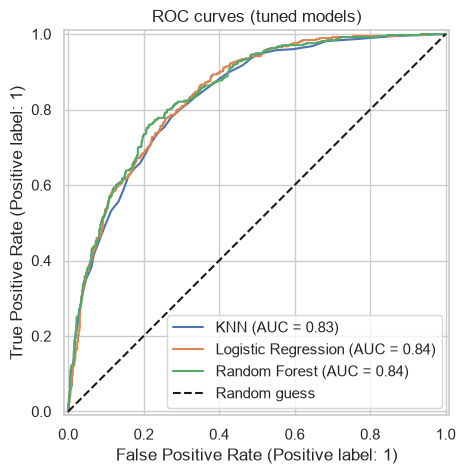

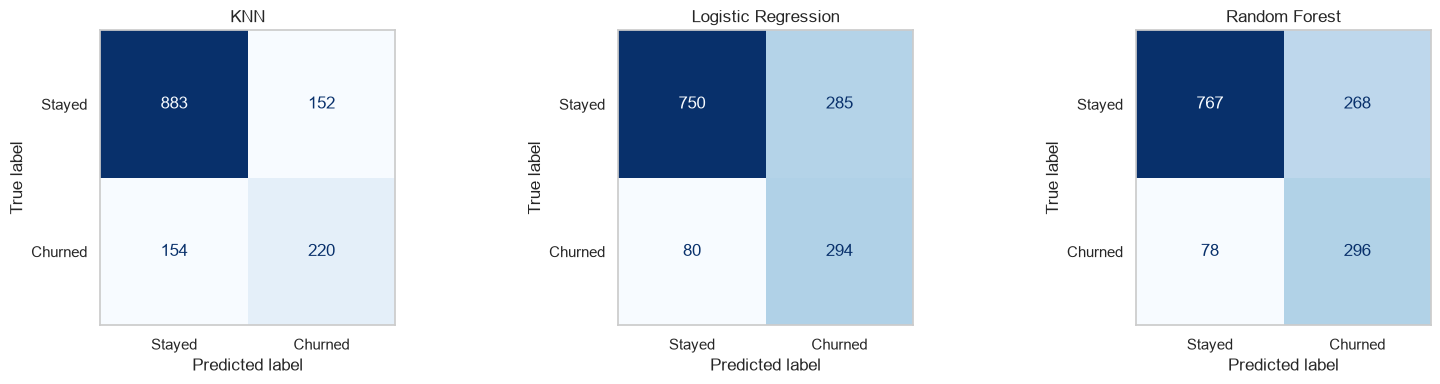

In [17]:
# ROC curves and confusion matrices
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_title("ROC curves (tuned models)")
ax.legend()
plt.savefig("figures/05_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, model) in zip(axes, best_models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap="Blues",
                                          display_labels=["Stayed", "Churned"], colorbar=False)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.savefig("figures/06_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

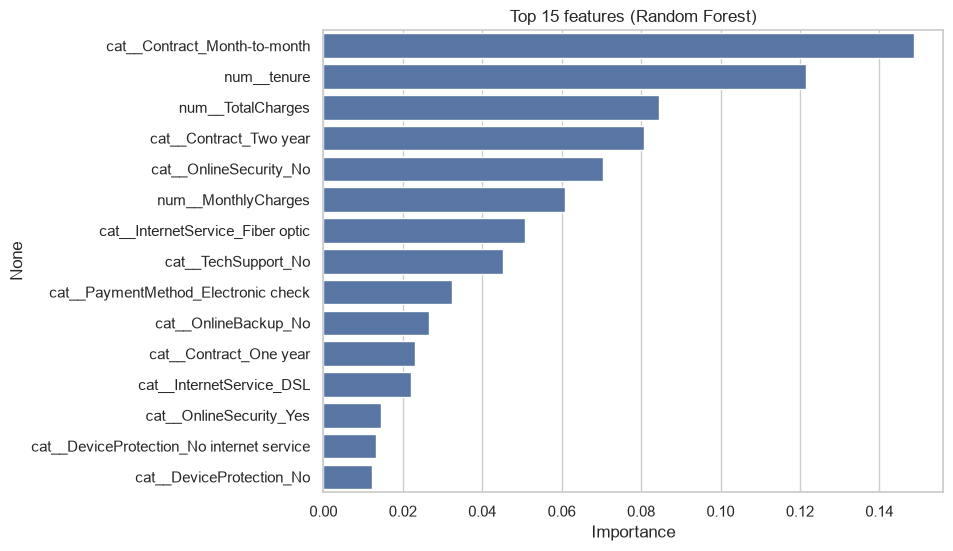

In [18]:
# which feature matter most?
rf = best_models["Random Forest"]
feature_names = rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf.named_steps["model"].feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 15 features (Random Forest)")
plt.xlabel("Importance")
plt.savefig("figures/07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Feature engineering

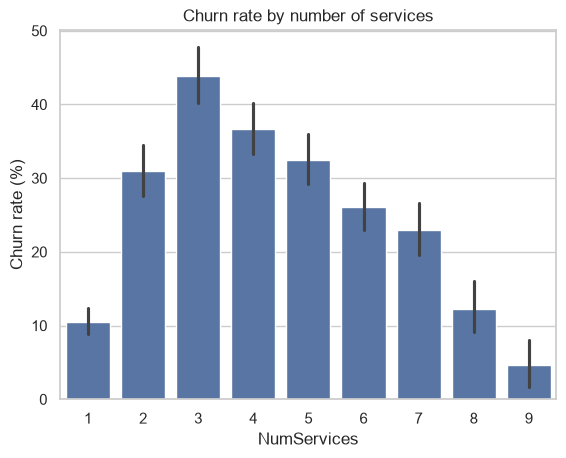

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumServices,TenureGroup
3738,Male,No,No,No,35,No,No,DSL,No,No,...,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,4,25-48
3151,Male,No,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,...,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,3,13-24
4860,Male,No,Yes,Yes,13,No,No,DSL,Yes,Yes,...,Yes,No,No,Two year,No,Mailed check,40.55,590.35,4,13-24
3867,Female,No,Yes,No,26,Yes,No,DSL,No,Yes,...,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,6,25-48
3810,Male,No,Yes,Yes,1,Yes,No,DSL,No,No,...,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,2,0-12


In [19]:
# feature engineering
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

def engineer(data):
    data = data.copy()
    # "No internet service" / "No phone service" repeat what InternetService / PhoneService already say
    for col in service_cols:
        data[col] = data[col].replace({"No internet service": "No", "No phone service": "No"})
    # how many services the customer has signed up for
    data["NumServices"] = (data[service_cols] == "Yes").sum(axis=1) + (data["InternetService"] != "No")
    # tenure bands (churn falls sharply in the first year)
    data["TenureGroup"] = pd.cut(data["tenure"], bins=[-1, 12, 24, 48, 72],
                                 labels=["0-12", "13-24", "25-48", "49-72"]).astype(str)
    return data

X_train_fe = engineer(X_train)
X_test_fe = engineer(X_test)

# churn rate by number of services (training data only)
sns.barplot(x=X_train_fe["NumServices"], y=y_train * 100)
plt.title("Churn rate by number of services")
plt.ylabel("Churn rate (%)")
plt.savefig("figures/08_num_services.png", dpi=150, bbox_inches="tight")
plt.show()
X_train_fe.head()

In [20]:
# Experiment 3, do the engineered features help? (5-fold CV on the training set)
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

fe_num = ["tenure", "MonthlyCharges", "TotalCharges", "NumServices"]
fe_cat = [c for c in X_train_fe.columns if c not in fe_num]
preprocess_fe = ColumnTransformer([
    ("num", StandardScaler(), fe_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), fe_cat),
])

fe_rows = []
for name, model in best_models.items():
    clf = model.named_steps["model"]
    base = cross_val_score(Pipeline([("prep", preprocess), ("model", clone(clf))]),
                           X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    eng = cross_val_score(Pipeline([("prep", preprocess_fe), ("model", clone(clf))]),
                          X_train_fe, y_train, cv=cv, scoring="f1", n_jobs=-1)
    fe_rows.append({"Model": name,
                    "Base F1": f"{base.mean():.3f} ± {base.std():.3f}",
                    "Engineered F1": f"{eng.mean():.3f} ± {eng.std():.3f}"})
pd.DataFrame(fe_rows)

,Model,Base F1,Engineered F1
0,KNN,0.610 ± 0.023,0.600 ± 0.016
1,Logistic Regression,0.629 ± 0.021,0.626 ± 0.020
2,Random Forest,0.634 ± 0.020,0.631 ± 0.019


**Churn by number of services:** churn peaks at 3 services (about 44%). It is low for phone-only customers (1 service, about 10%) and falls steadily for customers with many services (about 5% at 9). Customers who are heavily invested in the company's services rarely leave.

**Result:** the engineered features (merged "No internet/phone service" levels, NumServices, TenureGroup) did **not** improve cross-validated F1 for any model; every difference is within one standard deviation. They mostly re-express information already in tenure and the service columns, and Random Forest can already find tenure thresholds on its own. The baseline feature set is therefore kept for the final models. This is a useful negative result for the report.

## 8. Fairness checks

In [21]:
# Does the model treat groups fairly?
from sklearn.metrics import recall_score, precision_score

best = best_models["Random Forest"]
check = X_test.copy()
check["actual"] = y_test
check["predicted"] = best.predict(X_test)

def fairness_report(col):
    rows = []
    for group, g in check.groupby(col):
        rows.append({
            col: group,
            "Customers": len(g),
            "Actual churn %": round(g["actual"].mean() * 100, 1),
            "Flagged as churn %": round(g["predicted"].mean() * 100, 1),
            "Recall": round(recall_score(g["actual"], g["predicted"]), 3),
            "Precision": round(precision_score(g["actual"], g["predicted"]), 3),
        })
    return pd.DataFrame(rows)

for col in ["gender", "SeniorCitizen"]:
    display(fairness_report(col))

,gender,Customers,Actual churn %,Flagged as churn %,Recall,Precision
0,Female,687,28.1,39.2,0.772,0.554
1,Male,722,25.1,40.9,0.812,0.498


,SeniorCitizen,Customers,Actual churn %,Flagged as churn %,Recall,Precision
0,No,1187,23.3,35.5,0.754,0.494
1,Yes,222,44.1,64.4,0.898,0.615


In [22]:
# Is gender needed at all?
from sklearn.base import clone

X_train_ng = X_train.drop(columns="gender")
X_test_ng = X_test.drop(columns="gender")

prep_ng = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), [c for c in cat_cols if c != "gender"]),
])
rf_ng = Pipeline([("prep", prep_ng), ("model", clone(best.named_steps["model"]))])
rf_ng.fit(X_train_ng, y_train)

print("With gender    F1:", round(f1_score(y_test, best.predict(X_test)), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, best.predict_proba(X_test)[:, 1]), 3))
print("Without gender F1:", round(f1_score(y_test, rf_ng.predict(X_test_ng)), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, rf_ng.predict_proba(X_test_ng)[:, 1]), 3))

With gender    F1: 0.631  ROC-AUC: 0.844
Without gender F1: 0.634  ROC-AUC: 0.843


**Fairness findings:**
- **Gender:** recall and flag rates are similar for men and women, and removing gender changes F1 by only +0.003 and ROC-AUC by −0.001. Gender can be dropped without losing performance.
- **SeniorCitizen:** the model flags 64.4% of senior citizens as churners, although 44.1% actually churn. This over-flagging could lead to seniors being treated differently, for example being targeted with more retention offers or price changes. It should be monitored and discussed in the ethics section.